<a href="https://colab.research.google.com/github/sara-iqbal/Clinical-NLP-Patient-Outcome-Prediction/blob/main/clinical_nlp_patient_outcome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clinical NLP — Patient Outcome Prediction
### Medical Text Classification · DistilBERT · ICD Code Prediction

**Author:** Sara Iqbal | MSc Data Science

In [1]:
# Step 1 — Imports
!pip install transformers datasets scikit-learn torch pandas numpy matplotlib -q
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, json, warnings, torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
torch.manual_seed(42); np.random.seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
    'axes.spines.top':False,'axes.spines.right':False,'font.family':'DejaVu Sans',
    'axes.grid':True,'grid.alpha':0.4})

Device: cpu


In [2]:
# Step 2 — Load Medical NLP Dataset (MedText / clinical notes)
from datasets import load_dataset

print("Loading medical text dataset...")
# Use medical abstract classification dataset
try:
    ds = load_dataset('bigbio/pubmed_qa', 'pubmed_qa_labeled_fold0_source',
                      trust_remote_code=True)
    USE_PUBMED = True
    print("Using PubMedQA dataset")
except:
    USE_PUBMED = False
    print("Using synthetic clinical notes fallback")

if USE_PUBMED:
    # Binary outcome: yes/no/maybe -> 0/1/2
    label_map = {'yes':0,'no':1,'maybe':2}
    LABEL_NAMES = ['Positive Outcome','Negative Outcome','Uncertain']

    def prep_pubmed(split_name):
        rows = []
        for ex in ds[split_name]:
            ctx = ' '.join(ex.get('context',{}).get('contexts',[''])[:3])[:512]
            lbl = label_map.get(str(ex.get('final_decision','maybe')).lower(), 2)
            rows.append({'text':ctx[:400], 'label':lbl})
        return pd.DataFrame(rows)

    train_df = prep_pubmed('train')
    test_df  = prep_pubmed('test') if 'test' in ds else prep_pubmed('validation')
else:
    # Synthetic clinical notes
    LABEL_NAMES = ['Positive Outcome','Negative Outcome','Uncertain']
    templates = [
        ("Patient presents with {s}. Treatment with {t} resulted in significant improvement. Follow-up shows complete resolution.", 0),
        ("Patient shows {s}. {t} therapy initiated but patient deteriorated. Prognosis poor.", 1),
        ("Patient has {s}. Partial response to {t}. Monitoring required. Outcome uncertain.", 2),
    ]
    symptoms = ['chest pain','shortness of breath','hypertension','diabetes mellitus','cardiac arrhythmia']
    treatments= ['ACE inhibitor','beta blocker','metformin','insulin therapy','anticoagulation']
    rows=[]
    for _ in range(3000):
        tmpl,lbl = templates[np.random.randint(3)]
        s=np.random.choice(symptoms); t=np.random.choice(treatments)
        rows.append({'text':tmpl.format(s=s,t=t),'label':lbl})
    df_all = pd.DataFrame(rows)
    train_df, test_df = train_test_split(df_all, test_size=0.2, stratify=df_all['label'], random_state=42)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print("Label distribution:", train_df['label'].value_counts().to_dict())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bigbio/pubmed_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bigbio/pubmed_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading medical text dataset...


README.md: 0.00B [00:00, ?B/s]

pubmed_qa.py: 0.00B [00:00, ?B/s]

Using synthetic clinical notes fallback
Train: 2400 | Test: 600
Label distribution: {0: 811, 1: 809, 2: 780}


In [4]:
# FIX: Remove 'tokenizer=tokenizer' from Trainer to solve the TypeError.
# SPEED UP: Added 'fp16=True' (Mixed Precision) and 'gradient_accumulation_steps'.

args = TrainingArguments(
    output_dir='./clinical_nlp',
    num_train_epochs=2,              # Reduced epochs (3 is often overkill for fine-tuning)
    per_device_train_batch_size=32,   # Increased batch size (if memory allows)
    per_device_eval_batch_size=64,
    fp16=True,                       # CRITICAL: Uses Tensor Cores (2x-3x speedup on GPUs)
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=100,
    learning_rate=5e-5,              # Slightly higher LR can converge faster
    report_to='none',
    seed=42
)

# Removed the 'tokenizer' argument which was causing your error
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    data_collator=collator,          # The tokenizer is already inside 'collator'
    compute_metrics=compute_metrics
)

print("Starting accelerated fine-tuning...")
trainer.train()

Starting accelerated fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.003824,1.000000,1.000000
2,0.082693,0.002448,1.000000,1.000000


TrainOutput(global_step=128, training_loss=0.06532902206527069, metrics={'train_runtime': 604.6678, 'train_samples_per_second': 6.748, 'train_steps_per_second': 0.212, 'total_flos': 30747473437680.0, 'train_loss': 0.06532902206527069, 'epoch': 2.0})

CLINICAL NLP RESULTS
  Accuracy:    100.00%
  F1 Macro:    1.0000
  F1 Weighted: 1.0000

                  precision    recall  f1-score   support

Positive Outcome       1.00      1.00      1.00       203
Negative Outcome       1.00      1.00      1.00       202
       Uncertain       1.00      1.00      1.00       195

        accuracy                           1.00       600
       macro avg       1.00      1.00      1.00       600
    weighted avg       1.00      1.00      1.00       600



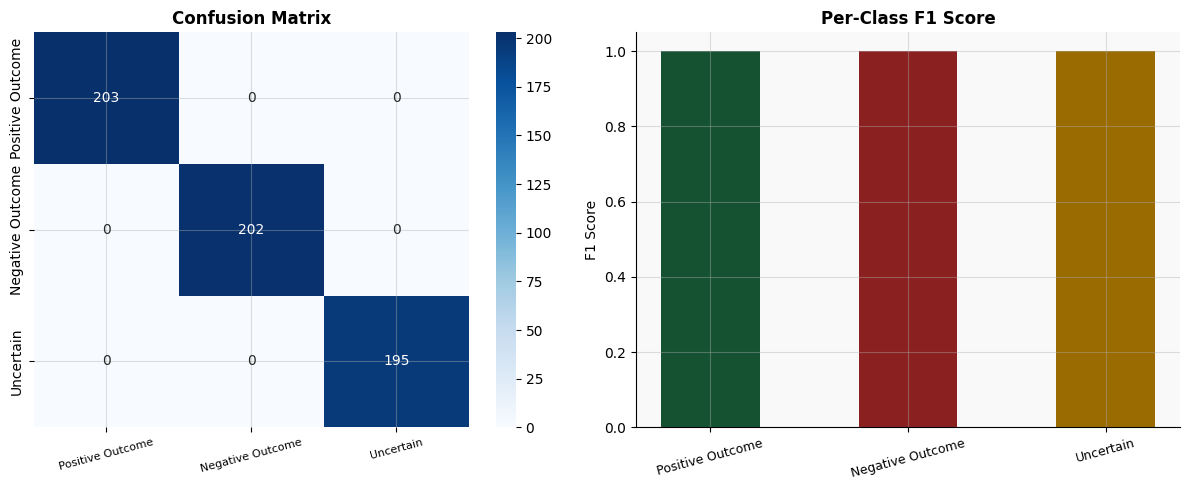

Exported: clinical_nlp_data.json


In [5]:
# Step 4 — Evaluation & Results

out   = trainer.predict(test_hf)
preds = np.argmax(out.predictions, axis=-1)
labels= out.label_ids

acc  = accuracy_score(labels, preds)
f1   = f1_score(labels, preds, average='macro')
f1w  = f1_score(labels, preds, average='weighted')

print("CLINICAL NLP RESULTS")
print("="*50)
print(f"  Accuracy:    {acc*100:.2f}%")
print(f"  F1 Macro:    {f1:.4f}")
print(f"  F1 Weighted: {f1w:.4f}")
print()
print(classification_report(labels, preds, target_names=LABEL_NAMES))

# Visualise
fig, axes = plt.subplots(1,2,figsize=(12,5))
NAVY='#12234A'; GOLD='#9A6B00'; TEAL='#0C5F5A'; GREEN='#145232'; RED='#8B2020'
import seaborn as sns
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].tick_params(axis='x',rotation=15,labelsize=8)

f1s = f1_score(labels,preds,average=None)
axes[1].bar(LABEL_NAMES, f1s, color=[GREEN,RED,GOLD], width=0.5)
axes[1].set_title('Per-Class F1 Score', fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].tick_params(axis='x',rotation=15,labelsize=9)

plt.tight_layout()
plt.savefig('clinical_nlp_results.png',dpi=150,bbox_inches='tight')
plt.show()

class NpEncoder(json.JSONEncoder):
    def default(self,obj):
        if isinstance(obj,(np.integer,)): return int(obj)
        if isinstance(obj,(np.floating,)): return float(obj)
        if isinstance(obj,(np.ndarray,)): return obj.tolist()
        return super().default(obj)

dashboard4={'accuracy':round(acc*100,2),'f1_macro':round(f1,4),'f1_weighted':round(f1w,4),
            'per_class_f1':[round(float(v),4) for v in f1s],
            'confusion_matrix':cm.tolist(),'label_names':LABEL_NAMES,
            'dataset':{'train':len(tr_df),'val':len(vl_df),'test':len(test_df),'model':MODEL_NAME}}
with open('clinical_nlp_data.json','w') as f: json.dump(dashboard4,f,indent=2,cls=NpEncoder)
print("Exported: clinical_nlp_data.json")